# PLANTEAMIENTO DEL PROBLEMA

Una compañia de telecomunicaciones tiene un enorme inconveniente para poder atender sus reclamos por tickets de fallas cuando ocurre un caso masivo, se satura la bandeja de entrada y no se le brinda la atencion rapida al cliente lo que causa molestia por los largos tiempos de espera que tienen que padecer los clientes para poder ser atendidos por soporte tecnico.

# SOLUCION

SE NECESITA UN ALGORITMO DE MACHINE LEARNING (IA) QUE PUEDA DETECTAR Y CLASIFICAR LOS CASOS DE FALLAS MASIVAS Y CASOS DE FALLAS PUNTUALES, EN TIEMPO REAL. PARA ESTO TOMANDO EN CONSIDERACION UNA TABLA DE DATOS EN EXCEL EN FORMATO CSV CON 1000 EJEMPLOS DIFERENTES DE TODAS LAS CARACTERISTICAS QUE SE TOMAN EN CUENTA PARA CLASIFICAR UNA FALLA COMO MASIVA Y OTRA COMO PUNTUAL Y DE ESTA FORMA NO SATURAR LA BANDEJA DE ENTRADA Y SOLVENTAR LOS CASOS MASIVOS EN OTRA BANDEJA APARTE O AUTOMATICAMENTE. ADICIONAL A ELLO EL ALGORITMO DE MACHINE LEARNING SERA CAPAZ DE PREDECIR CUANDO SE PODRIA PRESENTAR UNA FALLA MASIVA EN EL FUTURO.

# INICIEMOS LA CONSTRUCION DEL CEREBRO DE ESTE ALGORITMO CLASIFICADOR DE FALLAS MASIVAS

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn import metrics
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib.colors import LogNorm
from sklearn.metrics import f1_score

#lectura del conjunto de datos fallas/telecom
df = pd.read_csv("/content/fallas_telecom_100000.csv")
import re

def time_to_minutes(time_str):
    if pd.isna(time_str): return None
    time_str = time_str.lower().replace('.', '') # Estandarizar y limpiar

    # Expresión regular para capturar la hora, los minutos y el indicador am/pm
    match = re.match(r'(\d{1,2}):(\d{2})\s*(am|pm)?', time_str)
    if not match: return None

    hour, minute, ampm = match.groups()
    hour, minute = int(hour), int(minute)

    if ampm == 'pm' and hour != 12: hour += 12
    elif ampm == 'am' and hour == 12: hour = 0 # 12 AM es la medianoche

    return hour * 60 + minute

# Aplicar la función al DataFrame original
df['Hora de afectacion_num'] = df['Hora de afectación'].apply(time_to_minutes)

df

,OLT,Tarjeta,Puerto,Clientes afectados,Hora de afectación,CLASE,Hora de afectacion_num
0,mbo-bvis-olt-03,1,8,16,10:58 a.m.,Masivo,658
1,mbo-bvis-olt-05,2,12,5,12:00 am,Puntual,0
2,mbo-lpue-olt-00,1,0,8,4:50 am,Masivo,290
3,mbo-call-olt-05,1,0,40,3:26 pm,Masivo,926
4,mbo-lpue-olt-00,1,3,2,1:52 pm,Puntual,832
...,...,...,...,...,...,...,...
99995,mbo-call-olt-05,2,11,24,9:15 a.m.,Masivo,555
99996,mbo-bvis-olt-03,7,2,5,1:51 am,Puntual,111
99997,mbo-bvis-olt-03,7,1,5,4:35 pm,Puntual,995
99998,flc-coro-olt-04,3,12,1,9:34 am,Puntual,574


IMPORTANDO TODAS LAS LIBRERIAS QUE NECESITAMOS Y LA TABLA DE DATOS DE NUESTRO DATA SET, AHORA TOCA VECTORIZAR EL DATASET

In [4]:

#creamos una funcion que separe el df en 3 sub conjuntos diferentes
#train_set 60%, val_set 20% test_set 20%
#funciones auxiliares
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify is not None else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify is not None else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)



In [5]:
train_set, val_set, test_set = train_val_test_split(df, stratify='CLASE')

En la parte de codigo de arriba creamos una funcion que hace el particionado del conjunto de datos, y los guarda en las variables set de entrenamiento, set de validacion y set de pruebas.

In [6]:

#imprimimos los % de cada subconjunto esto se hace para entrenar mejor el algoritmo
print("Longitud del Training Set:", len(train_set))
print("Longitud del Validation Set:", len(val_set))
print("Longitud del Test Set:", len(test_set))



Longitud del Training Set: 60000
Longitud del Validation Set: 20000
Longitud del Test Set: 20000


observamos la longuitud de los datos guardados. para entrenar el algoritmo tenemos 600 ejemplos y la validacion del algoritmo son 200 y para probar el algoritmo son 200




AHORA PARA UTILIZAR ALGUN ALGORITMO PREDICTIVO ES NECESARIO QUE EL CONJUNTO DE DATOS NO TENGA DATOS CATEGORICOS NI DATOS NULOS.

ESTO SUCEDE PORQUE EL ALGORITMO PREDICTIVO SOLO ENTIENDE DE NUMEROS NO DE LETRAS. POR TANTO HAY QUE TRANSFORMAR EL CONJUNTO DE DATOS CON UNA TUBERIA (PIPELINE) PARA LIMPIAR ESTOS DATOS CON LA TECNICA ONE HOT ENCODED

No necesariamente se utilizan las mismas transformaciones cada columna por eso separamos el conjunto de datos en X , Y donde X son las caracteristicas, y Es la estiqueta final en base a las caracteristicas.

In [7]:
#Separemos las etiquetas para tener el conjunto de datos limpio
#definir el x,y Del conjunto de datos
X_train = train_set.drop("CLASE", axis=1)
y_train = train_set["CLASE"]



In [8]:
#PARA UTILIZAR SVM NECESITAMOS X, Y de cada division
X_val = val_set.drop("CLASE", axis=1)
y_val = val_set["CLASE"]

X_test = test_set.drop("CLASE", axis=1)
y_test = test_set["CLASE"]

In [9]:
y_train.value_counts()
#conjunto de datos desnivelado levemente, al definir nuestras clases

,count
CLASE,
Masivo,35198
Puntual,24802


PARA ESTE CONJUNTO DE 1000 DATOS DE FALLAS OBSERVAMOS QUE 353 DE ESAS FALLAS SON MASIVAS Y 247 CASOS PUNTUALES

In [10]:
X_train.head(28)

,OLT,Tarjeta,Puerto,Clientes afectados,Hora de afectación,Hora de afectacion_num
73873,mbo-call-olt-05,7,14,28,6:06 am,366
58091,mbo-call-olt-05,7,8,3,7:19 am,439
94947,mbo-bvis-olt-01,5,15,2,8:27 p.m.,1227
7767,mbo-lpue-olt-00,5,9,7,7:59 am,479
66150,mbo-call-olt-02,1,13,3,9:16 am,556
52500,mbo-call-olt-05,1,13,9,1:03 a.m.,63
42988,mbo-lpue-olt-00,6,11,10,3:33 p.m.,933
51942,mbo-lpue-olt-00,7,14,1,12:25 pm,745
8557,mbo-bvis-olt-01,3,13,3,2:56 a.m.,176
65359,mbo-lpue-olt-00,2,6,27,8:54 am,534


Empezamos ahora construyendo una tuberia para el dataset

In [11]:
# Construcción de un pipeline para los atributos numéricos (NULOS)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

#pipeline significa tuberia se utiliza para Limpiar el dataset
#para que el algoritmo pueda digerir el data set

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('rbst_scaler', RobustScaler()),
    ])

a continuacion todos los pipelines para transformar nuestro conjunto de datos, INCLUYENDO EL PIPELINE DE DATOS CATEGORICOS QUE NOS INTERESA ESPECIALMENTE PARA ESTE CONJUNTO DE DATOS

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
#colum transformer concatena todos los pipelines es como una tuberia grandisima
#ONEHOT ENCODED CONVIERTE A NUMERICOS LOS DATOS CATEGORICOS PARA QUE PUEDA LEEER EL ALGORITMO

num_attribs = list(X_train.select_dtypes(exclude=['object']))
#ponemos en una variable los datos categoricos que tenemos en nuestra etiqueta x
cat_attribs = list(X_train.select_dtypes(include=['object']))

# Obtener todas las categorías únicas de X_train para cada atributo categórico
ohe_categories = [X_train[col].unique() for col in cat_attribs]

# transformador de culumnas a numeros en vez de datos categoricos
# creamos la tuberia para transformar el dataset
full_pipeline = ColumnTransformer(
        [("num", num_pipeline, num_attribs),
         ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore', categories=ohe_categories), cat_attribs)],
        remainder='passthrough'
    )

FIJEMONOS EN ESTO CONSTRUIMOS 2 TUBERIAS APARTE Y LAS METIMOS EN UNA SOLA TUBERIA QUE TRANSFORMA AMBOS DATOS TANTOS LOS NULOS COMO LOS CATEGORICOS LLAMADA FULL PIPELINE y con esa tuberia final transformamos nuestro data set x para entrenar el algoritmo

In [16]:
#conjunto de datos X preparado para entrenar el algoritmo
X_train_prep = full_pipeline.fit_transform(X_train)
x_test_test = full_pipeline.fit_transform(X_test)
x_val_val = full_pipeline.fit_transform(X_val)
# Obtener los nombres de las características después de la transformación

feature_names = full_pipeline.get_feature_names_out()

#aqui queremos representar el conjunto de datos manteniendo sus columnas originales con sus nombres
X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names, index=X_train.index)
X_val_prep = pd.DataFrame(x_val_val, columns=feature_names, index=X_val.index)
X_test_prep = pd.DataFrame(x_test_test, columns=feature_names, index=X_test.index)



AHORA PODREMOS VER EL DATA SET COMPLETO YA ESCALADO SIN DATOS CATEGORICOS NI VALORES NULOS PARA QUE EL ALGORITMO LO PUEDA DIGERIR Y MANIPULAR

In [17]:
X_train_prep.head(10)

,num__Tarjeta,num__Puerto,num__Clientes afectados,num__Hora de afectacion_num,cat__OLT_mbo-call-olt-05,cat__OLT_mbo-bvis-olt-01,cat__OLT_mbo-lpue-olt-00,cat__OLT_mbo-call-olt-02,cat__OLT_mbo-bvis-olt-03,cat__OLT_flc-coro-olt-01,...,cat__Hora de afectación_9:51 a.m.,cat__Hora de afectación_9:15 p.m.,cat__Hora de afectación_5:55 a.m.,cat__Hora de afectación_2:19 a.m.,cat__Hora de afectación_8:58 a.m.,cat__Hora de afectación_12:05 p.m.,cat__Hora de afectación_6:03 p.m.,cat__Hora de afectación_11:24 p.m.,cat__Hora de afectación_7:52 p.m.,cat__Hora de afectación_3:36 a.m.
73873,0.75,0.750,1.333333,-0.493706,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58091,0.75,0.000,-0.333333,-0.391608,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
94947,0.25,0.875,-0.400000,0.710490,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7767,0.25,0.125,-0.066667,-0.335664,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66150,-0.75,0.625,-0.333333,-0.227972,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52500,-0.75,0.625,0.066667,-0.917483,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42988,0.50,0.375,0.133333,0.299301,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51942,0.75,0.750,-0.466667,0.036364,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8557,-0.25,0.625,-0.333333,-0.759441,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65359,-0.50,-0.250,1.266667,-0.258741,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


PODREMOS VER TODOS LOS DATA SETS LISTOS PARA ENTRENARSE TANTO EL DE ENTRENAMIENTO , EL DE VALIDACION Y EL DE PRUEBAS

In [18]:
X_test_prep.head(10)

,num__Tarjeta,num__Puerto,num__Clientes afectados,num__Hora de afectacion_num,cat__OLT_mbo-call-olt-05,cat__OLT_mbo-bvis-olt-01,cat__OLT_mbo-lpue-olt-00,cat__OLT_mbo-call-olt-02,cat__OLT_mbo-bvis-olt-03,cat__OLT_flc-coro-olt-01,...,cat__Hora de afectación_9:51 a.m.,cat__Hora de afectación_9:15 p.m.,cat__Hora de afectación_5:55 a.m.,cat__Hora de afectación_2:19 a.m.,cat__Hora de afectación_8:58 a.m.,cat__Hora de afectación_12:05 p.m.,cat__Hora de afectación_6:03 p.m.,cat__Hora de afectación_11:24 p.m.,cat__Hora de afectación_7:52 p.m.,cat__Hora de afectación_3:36 a.m.
56160,0.50,-0.555556,-0.466667,-0.808377,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3115,-0.75,0.333333,0.533333,0.896335,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44358,0.75,-0.333333,0.733333,-0.256894,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49796,0.50,0.888889,0.000000,-0.403490,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33963,0.00,-0.444444,-0.400000,0.284817,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53811,-0.25,0.444444,-0.466667,0.340663,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18205,-0.50,-0.111111,-0.466667,-0.834904,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9747,-0.50,-0.777778,3.000000,0.643630,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17878,-0.75,0.000000,-0.266667,-0.846073,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39774,0.25,-0.111111,2.933333,0.097731,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
X_val_prep.head(10)

,num__Tarjeta,num__Puerto,num__Clientes afectados,num__Hora de afectacion_num,cat__OLT_mbo-call-olt-05,cat__OLT_mbo-bvis-olt-01,cat__OLT_mbo-lpue-olt-00,cat__OLT_mbo-call-olt-02,cat__OLT_mbo-bvis-olt-03,cat__OLT_flc-coro-olt-01,...,cat__Hora de afectación_9:51 a.m.,cat__Hora de afectación_9:15 p.m.,cat__Hora de afectación_5:55 a.m.,cat__Hora de afectación_2:19 a.m.,cat__Hora de afectación_8:58 a.m.,cat__Hora de afectación_12:05 p.m.,cat__Hora de afectación_6:03 p.m.,cat__Hora de afectación_11:24 p.m.,cat__Hora de afectación_7:52 p.m.,cat__Hora de afectación_3:36 a.m.
78149,-0.50,0.250,-0.4375,0.344444,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20220,0.25,-0.750,1.2500,-0.475000,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74962,0.00,-0.875,1.1875,-0.931944,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59203,-0.50,-0.875,0.6250,-0.595833,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
95919,0.00,0.125,-0.0625,0.440278,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
93176,0.75,0.250,0.1250,-0.283333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9440,-0.50,-0.375,1.0625,0.368056,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88041,0.25,0.375,-0.5000,-0.881944,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98246,0.00,-0.250,0.5000,-0.945833,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88482,0.75,-0.750,-0.3750,0.713889,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# EL CONJUNTO DE DATOS ESTA LISTO PARA EL ENTRENAMIENTO AHORA FALTA ELEGIR EL ALGORITMO PREDICTIVO ENTRE TANTOS, PARA SABER CUAL ALGORITMO ELEGIR PODEMOS GRAFICAR LAS CARACTERISTICAS MAS DETERMINANTES DEL MISMO ALGORITMO.

AHORA VAMOS AGRAFICAR TODAS LAS CARACTERISTICAS DEL CONJUNTO DE DATOS PARA VALIDAR CUALES CARACTERISTICAS SON LAS MAS DETERMINANTES

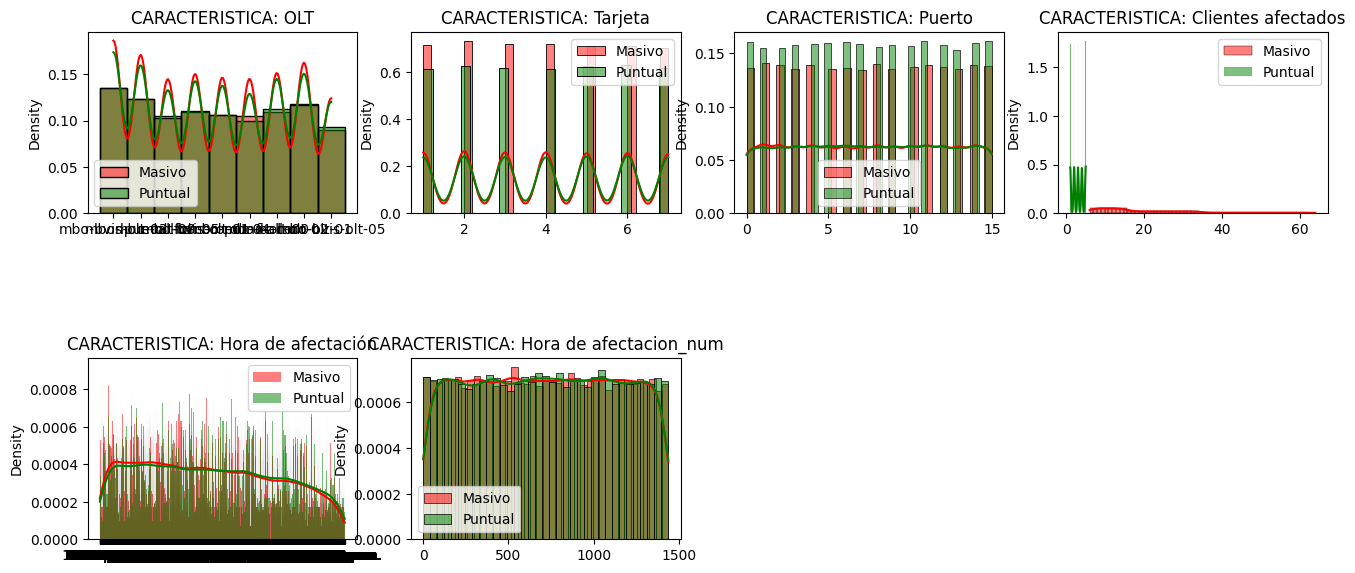

In [20]:
# Representamos gráficamente las características
features = df.drop("CLASE", axis=1)

plt.figure(figsize=(16, 32))
gs = gridspec.GridSpec(8, 4)
gs.update(hspace=0.8)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Usando histplot para los casos donde CLASE == 'Masivo'
    sns.histplot(data=df[df["CLASE"] == 'Masivo'], x=f, kde=True, color="red", stat="density", label="Masivo", alpha=0.5)
    # Usando histplot para los casos donde CLASE == 'Puntual'
    sns.histplot(data=df[df["CLASE"] == 'Puntual'], x=f, kde=True, color="green", stat="density", label="Puntual", alpha=0.5)
    ax.set_xlabel('')
    ax.set_title(f"CARACTERISTICA: {f}")
    ax.legend()

plt.show()

# COMO PODEMOS VER EN LA GRAFICA DE ARRIBA LAS CARACTERISTICAS MAS DETERMINANTES, ES DECIR LAS QUE MAS SEPARA LAS CLASES ES LA CARACTERISTICA DE "CLIENTES AFECTADOS"

AHORA GRAFICAREMOS LAS CARACTERISTICAS MAS DETERMINANTES DEL CONJUNTO DE DATOS que es Clientes afectados

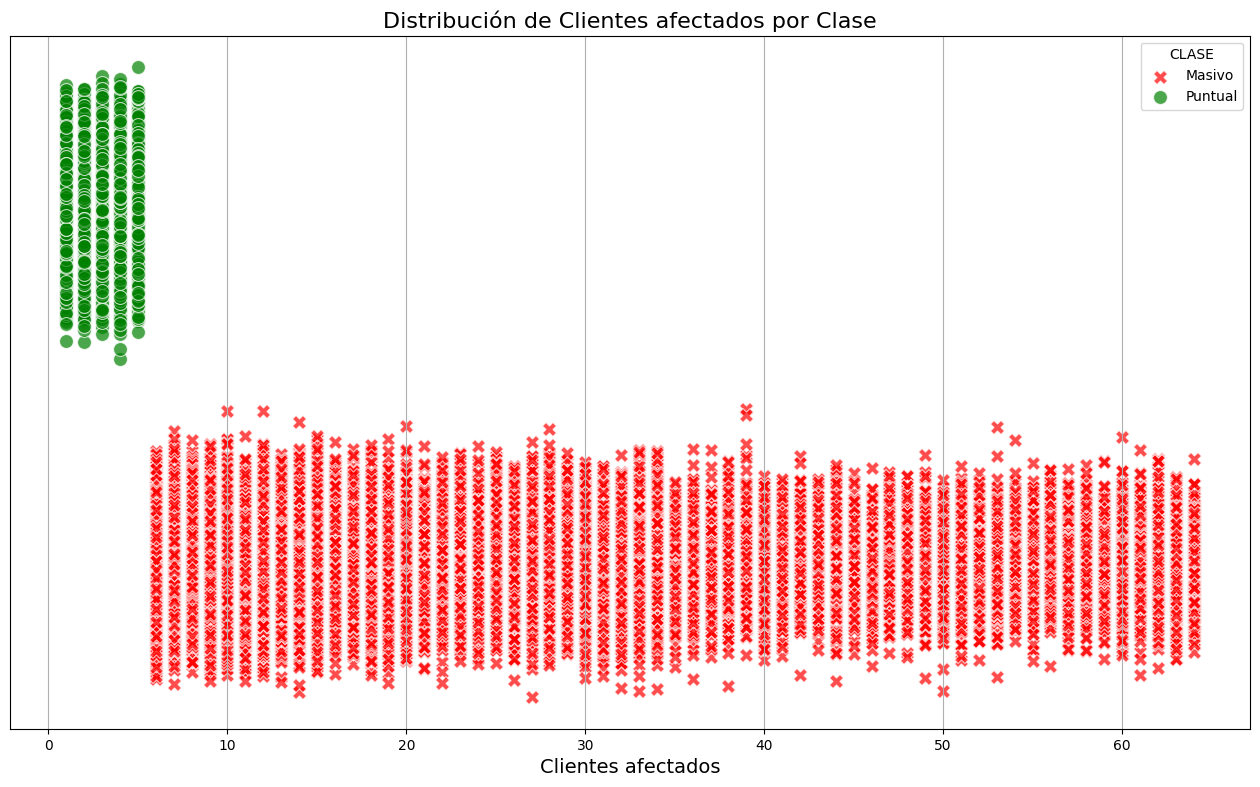

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Import numpy for random jitter

df = pd.read_csv("/content/fallas_telecom_100000.csv")

plt.figure(figsize=(16, 9))

# Plot 'Masivo' cases with 'X' markers and red color
sns.scatterplot(
    data=df[df['CLASE'] == 'Masivo'],
    x='Clientes afectados',
    y=np.random.normal(loc=0, scale=0.1, size=len(df[df['CLASE'] == 'Masivo'])), # Dummy y-axis with jitter
    marker='X',
    color='red',
    label='Masivo',
    s=100,
    alpha=0.7
)

# Plot 'Puntual' cases with 'o' markers and green color
sns.scatterplot(
    data=df[df['CLASE'] == 'Puntual'],
    x='Clientes afectados',
    y=np.random.normal(loc=1, scale=0.1, size=len(df[df['CLASE'] == 'Puntual'])), # Dummy y-axis with jitter
    marker='o',
    color='green',
    label='Puntual',
    s=100,
    alpha=0.7
)

plt.title('Distribución de Clientes afectados por Clase', fontsize=16)
plt.xlabel('Clientes afectados', fontsize=14)
plt.ylabel('') # Remove y-axis label
plt.yticks([])  # Hide y-axis ticks
plt.legend(title='CLASE')
plt.grid(True)
plt.show()

# AHORA SI OBSERVAMOS OTRA CARACTERISTICA GRAFICADA POR EJEMPLO PUERTO Y TARJETA VEMOS QUE NO DETERMINA TANTO LOS CASOS MASIVOS DE LOS PUNTUALES

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


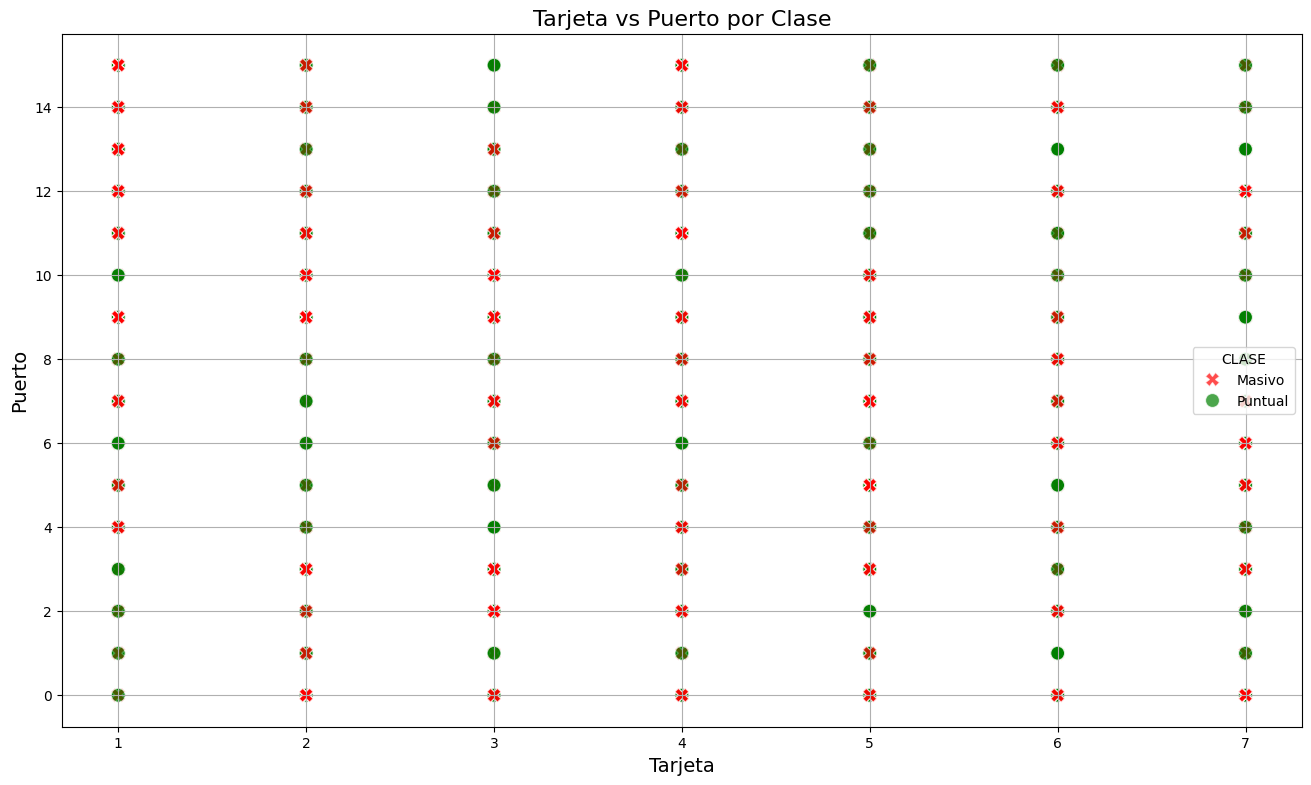

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("/content/fallas_telecom_100000.csv") # Load the DataFrame

plt.figure(figsize=(16, 9))
sns.scatterplot(
    data=df,
    x='Tarjeta',
    y='Puerto',
    hue='CLASE',              # Color represents the CLASE ('Masivo'/'Puntual')
    style='CLASE',              # Different markers for 'Masivo' and 'Puntual'
    palette={'Masivo': 'red', 'Puntual': 'green'}, # Custom colors for clarity
    markers={'Masivo': 'X', 'Puntual': 'o'}, # Changed 'x' to 'X' (filled cross) to match 'o' (filled circle)
    s=100,                       # Marker size
    alpha=0.7                   # Transparency
)

plt.title('Tarjeta vs Puerto por Clase', fontsize=16)
plt.xlabel('Tarjeta', fontsize=14)
plt.ylabel('Puerto', fontsize=14)
plt.legend(title='CLASE')
plt.grid(True)
plt.show()

# COMO PODEMOS OBSERVAR EN LA GRAFICA ANTERIOR LAS CARACTERISTICAS PARA CLASIFICAR MASIVOS O PUNTUALES SE PUEDEN SEPARAR LINEALMENTE SI SE TOMA LA CARACTERISTICA CLIENTES AFECTADOS . POR ESO EL ALGORITMO DE MACHINE LEARNING A UTILIZAR ES SUPORT VECTOR MACHINE O SVM, tambien se puede utilizar regresion logistica pero por prevision utilizaremos svm ya que cuenta con los limites y sera mas preciso.

No es necesario utilizar red neuronal porque el conjunto de datos es linealmente separable. si utilizaramos una red neuronal para este problema de clasificacion seria como matar un mosquito con una bazuca.

ROMPAMOS EL DF ORIGINAL YA QUE ELIINAREMOS LAS CARACTERISTICAS DE RUIDO

# EMPEZEMOS CON SUPPORT VECTOR MACHINE

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 1. Seleccionar únicamente la característica determinante
X = df[['Clientes afectados']]
y = df['CLASE']  # <--- Reemplaza con el nombre de tu columna objetivo

# 2. Dividir el conjunto de datos (70% entrenamiento, 30% prueba)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Escalar la característica (crucial para el rendimiento de SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)

# 4. Entrenar el SVM con un kernel lineal rígido
modelo_svm = SVC(kernel='linear', C=1.0)
modelo_svm.fit(X_train_scaled, y_train_new)

# 5. Evaluar los resultados en los datos nuevos (Test)
predicciones = modelo_svm.predict(X_test_scaled)

#NUEVO SET DE ENTRENAMIENTO PARA EL ALGORITMO CON LAS CARACTERISTICAS REDUCIDAS
print("Longitud del Training Set:", len(X_train_new))
print("Longitud del TEST Set:", len(X_test_new))





Longitud del Training Set: 70000
Longitud del TEST Set: 30000


In [23]:
y


,CLASE
0,Masivo
1,Puntual
2,Masivo
3,Masivo
4,Puntual
...,...
99995,Masivo
99996,Puntual
99997,Puntual
99998,Puntual


In [24]:
X


,Clientes afectados
0,16
1,5
2,8
3,40
4,2
...,...
99995,24
99996,5
99997,5
99998,1


PROBANDO EL CONJUNTO DE DATOS NUEVO DE ENTRENAMIENTO CON EL DE PRUEBAS NUEVO

# LAS PREDICIONES PARA LOS CASOS MASIVOS EN EL MODELO ENTRENADO CON EL DATASET REDUCIDO SON DEL 100%

In [27]:
from sklearn.metrics import f1_score
print("F1 Score:", f1_score(predicciones, y_test_new, pos_label='Masivo'))

F1 Score: 1.0


# AHORA CON CASOS PUNTUALES

In [28]:
print("F1 Score:", f1_score(predicciones, y_test_new, pos_label='Puntual'))

F1 Score: 1.0


EN AMBOS DATOS PREDIJO CON EL 100% DE ACERTIVIDAD PARA DATOS QUE NO HABIA VISTO NUNCA ANTES.

# AHORA CON EL DATA SET COMPLETO

# grafiquemos los limites de decision

In [29]:
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # Check if the decision boundary is vertical (w[1] is zero or very close to zero)
    if np.isclose(w[1], 0):
        if np.isclose(w[0], 0):
            # Both coefficients are zero, no meaningful boundary
            return
        # frontera del  limite vertical: x = -b/w[0]
        x_intercept = -b / w[0] # Corrected: b is already a scalar
        plt.plot([x_intercept, x_intercept], [plt.ylim()[0], plt.ylim()[1]], "k-", linewidth=2)

        # Calculate margin for vertical lines along the x-axis
        margin_x = 1 / np.abs(w[0]) if w[0] != 0 else float('inf')
        plt.plot([x_intercept + margin_x, x_intercept + margin_x], [plt.ylim()[0], plt.ylim()[1]], "k--", linewidth=2)
        plt.plot([x_intercept - margin_x, x_intercept - margin_x], [plt.ylim()[0], plt.ylim()[1]], "k--", linewidth=2)
    else:
        # Standard case: sloped line
        x0 = np.linspace(xmin, xmax, 200)
        decision_boundary = -w[0]/w[1] * x0 - b/w[1]

        # Margin offset in y-direction
        y_margin_offset = 1 / np.abs(w[1]) # Use absolute value to ensure correct visual margin direction
        gutter_up = decision_boundary + y_margin_offset
        gutter_down = decision_boundary - y_margin_offset

        plt.plot(x0, decision_boundary, "k-", linewidth=2)
        plt.plot(x0, gutter_up, "k--", linewidth=2)
        plt.plot(x0, gutter_down, "k--", linewidth=2)

    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')

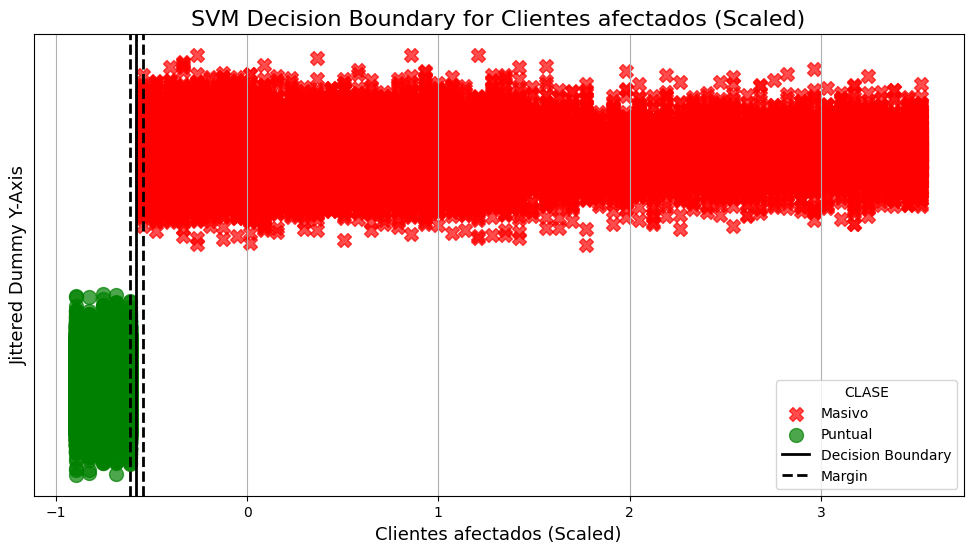

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Re-load DataFrame (for self-contained cell)
df = pd.read_csv("/content/fallas_telecom_100000.csv")

# 1. Select the determinant feature
X = df[['Clientes afectados']]
y = df['CLASE']

# 2. Split the dataset (70% training, 30% test)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Scale the feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_new)

# 4. Train the SVM
modelo_svm = SVC(kernel='linear', C=1.0)
modelo_svm.fit(X_train_scaled, y_train_new)

plt.figure(figsize=(12, 6))

# Plot 'Masivo' cases
masivo_data = X_train_scaled[y_train_new == 'Masivo']
plt.scatter(
    masivo_data,
    np.random.normal(loc=0.5, scale=0.1, size=len(masivo_data)),
    marker='X',
    color='red',
    label='Masivo',
    s=100,
    alpha=0.7
)

# Plot 'Puntual' cases
puntual_data = X_train_scaled[y_train_new == 'Puntual']
plt.scatter(
    puntual_data,
    np.random.normal(loc=-0.5, scale=0.1, size=len(puntual_data)),
    marker='o',
    color='green',
    label='Puntual',
    s=100,
    alpha=0.7
)

# Calculate and plot decision boundary for 1D feature
x_db = -modelo_svm.intercept_[0] / modelo_svm.coef_[0][0]
plt.axvline(x=x_db, color='k', linestyle='-', linewidth=2, label='Decision Boundary')

# Calculate and plot margins
margin = 1 / np.abs(modelo_svm.coef_[0][0])
plt.axvline(x=x_db + margin, color='k', linestyle='--', linewidth=2, label='Margin')
plt.axvline(x=x_db - margin, color='k', linestyle='--', linewidth=2)

plt.title('SVM Decision Boundary for Clientes afectados (Scaled)', fontsize=16)
plt.xlabel('Clientes afectados (Scaled)', fontsize=13)
plt.ylabel('Jittered Dummy Y-Axis', fontsize=13) # Renamed for clarity
plt.yticks([])  # Hide y-axis ticks as it's a dummy axis
plt.legend(title='CLASE')
plt.grid(True)
plt.show()

# Prediccion del conjunto de datos reducido

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 4. Entrenar el SVM con un kernel lineal rígido
modelo_svm = SVC(kernel='linear', C=1.0)
modelo_svm.fit(X_scaled, y)

SVC(kernel='linear')

In [36]:
y_pred = modelo_svm.predict(X_scaled)

# Prediccion de los casos masivos en el conjunto de datos reducido

In [37]:
print("F1 Score:", f1_score(y_pred, y, pos_label='Masivo'))

F1 Score: 1.0


# Prediccion del conjunto de datos reducido para casos Puntuales

In [38]:
print("F1 Score:", f1_score(y_pred, y, pos_label='Puntual'))

F1 Score: 1.0


100% DE ACIERTO EN PREDICION EN AMBAS CLASES PARA el conjunto de datos de entrenamiento completo cuando se enfrenta a datos nuevos.

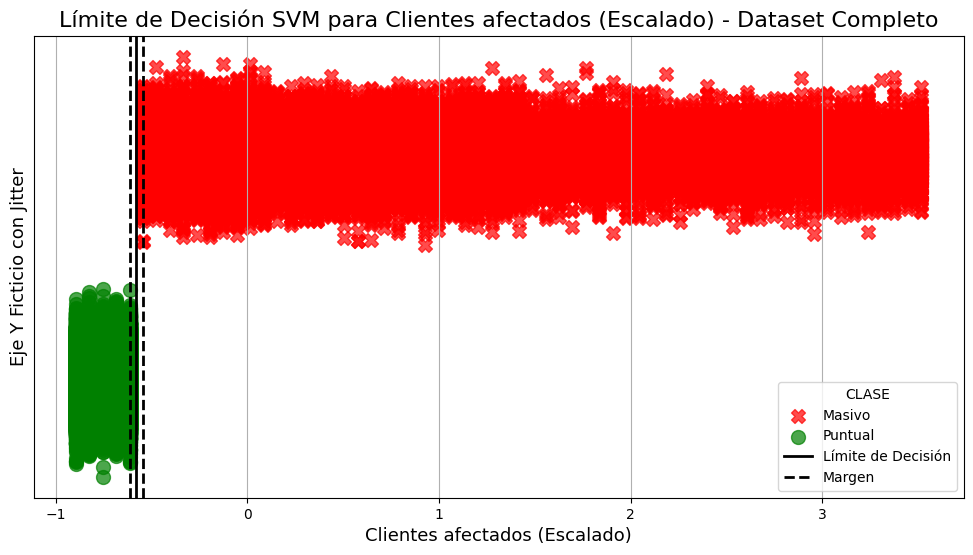

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Re-cargar DataFrame y re-escalar X y y para asegurar que estén disponibles en esta celda
df = pd.read_csv("/content/fallas_telecom_100000.csv")
X = df[['Clientes afectados']]
y = df['CLASE']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Re-entrenar el SVM para asegurar que 'modelo_svm' esté disponible y sea el correcto para X_scaled y y
# Se usa un C=1.0 para mantener la coherencia con el entrenamiento anterior
modelo_svm = SVC(kernel='linear', C=1.0)
modelo_svm.fit(X_scaled, y)

plt.figure(figsize=(12, 6))

# Graficar los casos 'Masivo'
masivo_data_full = X_scaled[y == 'Masivo']
plt.scatter(
    masivo_data_full,
    np.random.normal(loc=0.5, scale=0.1, size=len(masivo_data_full)),
    marker='X',
    color='red',
    label='Masivo',
    s=100,
    alpha=0.7
)

# Graficar los casos 'Puntual'
puntual_data_full = X_scaled[y == 'Puntual']
plt.scatter(
    puntual_data_full,
    np.random.normal(loc=-0.5, scale=0.1, size=len(puntual_data_full)),
    marker='o',
    color='green',
    label='Puntual',
    s=100,
    alpha=0.7
)

# Calcular y graficar el límite de decisión para la característica 1D
x_db = -modelo_svm.intercept_[0] / modelo_svm.coef_[0][0]
plt.axvline(x=x_db, color='k', linestyle='-', linewidth=2, label='Límite de Decisión')

# Calcular y graficar los márgenes
margin = 1 / np.abs(modelo_svm.coef_[0][0])
plt.axvline(x=x_db + margin, color='k', linestyle='--', linewidth=2, label='Margen')
plt.axvline(x=x_db - margin, color='k', linestyle='--', linewidth=2)

plt.title('Límite de Decisión SVM para Clientes afectados (Escalado) - Dataset Completo', fontsize=16)
plt.xlabel('Clientes afectados (Escalado)', fontsize=13)
plt.ylabel('Eje Y Ficticio con Jitter', fontsize=13) # Eje Y ficticio para visualización
plt.yticks([])  # Ocultar ticks del eje Y ya que es un eje ficticio
plt.legend(title='CLASE')
plt.grid(True)
plt.show()

# EL ALGORITMO DE MACHINE LEARNING ACIERTA CON EXACTITUD LOS 100000 DATOS DEL DATASET ASI QUE PUEDE Y CONSTRUYE LIMITES CON FRONTERAS DE DECISION ESPECIFICAS BASADAS EN SU ENTRENAMIENTO. ES DECIR EN CASO DE PRESENTARSE CASOS DE MASIVOS ANOMALOS PODRIA DETECTARLOS DEPENDIENDO DEL NIVEL DE LA ANOMALIA.